In [ ]:
# CIDAR10 dataset으로 분류기 생성 - CNN 있는 모델

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping


(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(f'Train data shape: {x_train.shape}, Train labels shape: {y_train.shape}')
# Train data shape: (50000, 32, 32, 3), Train labels shape: (50000, 1)
print(x_train[0])
print(y_train[0])   # [6] -> 6번 클래스 : frog
print('\n')

# 정규화
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


# One-hot 인코딩
NUM_CLASSES = 10
y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test = to_categorical(y_test, num_classes=NUM_CLASSES)
print(y_train[0])   # [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.] -> 6번 클래스 : frog

Train data shape: (50000, 32, 32, 3), Train labels shape: (50000, 1)
[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]
[6]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [2]:
# 모델 정의 Functional API
def conv_block(x, filters):
    x = layers.Conv2D(filters=filters, kernel_size=(3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)  # 배치 정규화 추가(학습이 안정적, 과적합 방지)
    x = layers.ReLU()(x)
    return x



inputs = layers.Input(shape=(32, 32, 3))
# Stage 1
x = conv_block(inputs, filters=32)
x = conv_block(x, filters=32)   # 2개의 컨볼루션 블록으로 구성된 스테이지
x = layers.MaxPooling2D()(x)


# Stage 2
x = conv_block(x, filters=64)
x = conv_block(x, filters=64)   # 2개의 컨볼루션 블록으로 구성된 스테이지
x = layers.MaxPooling2D()(x)


# Stage 3
x = conv_block(x, filters=128)
x = conv_block(x, filters=128)  # 2개의 컨볼루션 블록으로 구성된 스테이지
x = layers.MaxPooling2D()(x)


# Classifier 분류기
x = layers.GlobalAveragePooling2D()(x)  # 완전 연결층 대신 GAP 사용 → 4차원을 2차원으로 축소 ⇨ Flatten() 대신 사용
# CNN의 마지막 conv 출력이 (batch_size, hight, width, channels) 형태일 때, GAP는 각 채널에 대해 공간적 평균을 계산하여 (batch_size, channels) 형태로 변환
# GAP는 모델의 파라미터 수를 줄이고, 과적합을 방지하며, 다양한 입력 크기에 유연하게 대응할 수 있도록 도와줌
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)


model = models.Model(inputs=inputs, outputs=outputs, name='cifar10_cnn')
print(model.summary())

Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             

 Total params: 306,154 (1.17 MB)

 Trainable params: 305,258 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

None


In [5]:
# compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

es = EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True)

# fit
history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=128,
    shuffle=True,
    verbose=2,
    validation_split=0.1,
    callbacks=[es]
)


# 평가
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0, batch_size=128)
print(f'test acc : {test_acc:.4f}')
print(f'test loss : {test_loss:.4f}')

Epoch 1/100
352/352 - 17s - 49ms/step - accuracy: 0.8687 - loss: 0.3794 - val_accuracy: 0.7442 - val_loss: 0.8147
Epoch 2/100
352/352 - 5s - 15ms/step - accuracy: 0.8816 - loss: 0.3425 - val_accuracy: 0.7998 - val_loss: 0.6024
Epoch 3/100
352/352 - 5s - 14ms/step - accuracy: 0.8900 - loss: 0.3151 - val_accuracy: 0.7244 - val_loss: 0.9837
Epoch 4/100
352/352 - 5s - 14ms/step - accuracy: 0.9012 - loss: 0.2844 - val_accuracy: 0.7338 - val_loss: 0.9155
Epoch 5/100
352/352 - 5s - 15ms/step - accuracy: 0.9101 - loss: 0.2578 - val_accuracy: 0.7578 - val_loss: 0.8641
Epoch 6/100
352/352 - 5s - 14ms/step - accuracy: 0.9199 - loss: 0.2338 - val_accuracy: 0.7638 - val_loss: 0.8516
Epoch 7/100
352/352 - 5s - 15ms/step - accuracy: 0.9241 - loss: 0.2180 - val_accuracy: 0.8018 - val_loss: 0.7494
Epoch 8/100
352/352 - 5s - 14ms/step - accuracy: 0.9294 - loss: 0.2045 - val_accuracy: 0.7496 - val_loss: 0.9088
Epoch 9/100
352/352 - 5s - 15ms/step - accuracy: 0.9377 - loss: 0.1782 - val_accuracy: 0.7868 -

In [6]:
CLASSES = np.array([
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
])


# 에측
pred = model.predict(x_test)
pred = CLASSES[np.argmax(pred[:10], axis=-1)]   # 0 : 열 기준, 1 : 행 기준
actual = CLASSES[np.argmax(y_test[:10], axis=-1)]   # -1 : 행 단위 뒤에서 부터 처리


print('예측값 : ', pred)
print('실제값 : ', actual)
print('분류 실패 수 : ', (pred != actual).sum())

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
예측값 :  ['cat' 'automobile' 'ship' 'airplane' 'frog' 'frog' 'automobile' 'frog'
 'cat' 'automobile']
실제값 :  ['cat' 'ship' 'ship' 'airplane' 'frog' 'frog' 'automobile' 'frog' 'cat'
 'automobile']
분류 실패 수 :  1


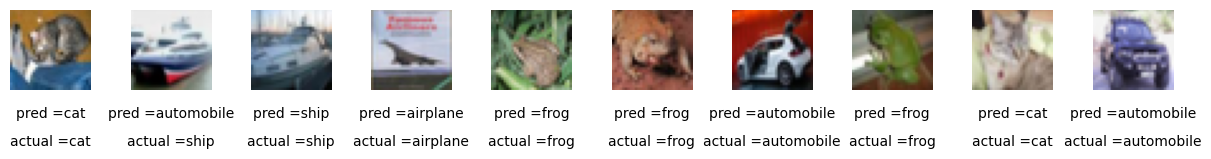

In [7]:
# 시각화
fig = plt.figure(figsize=(15, 3))
fig.subplots_adjust(hspace=0.5, wspace=0.5) # → subplot 사이 간격 조정

for i, idx in enumerate(range(len(x_test[:10]))):
    img = x_test[idx]
    ax = fig.add_subplot(1, len(x_test[:10]), i+1)
    ax.axis('off')
    ax.imshow(img)

    # transform=ax.transAxes : 축 좌표계로 텍스트 위치 지정, 이미지 픽셀 대신에 sbplot영역 기준 (0.5 → 중앙)
    ax.text(0.5, -0.35, 'pred =' + str(pred[idx]), fontsize=10, ha='center', transform=ax.transAxes)
    ax.text(0.5, -0.7, 'actual =' + str(actual[idx]), fontsize=10, ha='center', transform=ax.transAxes)

plt.show()